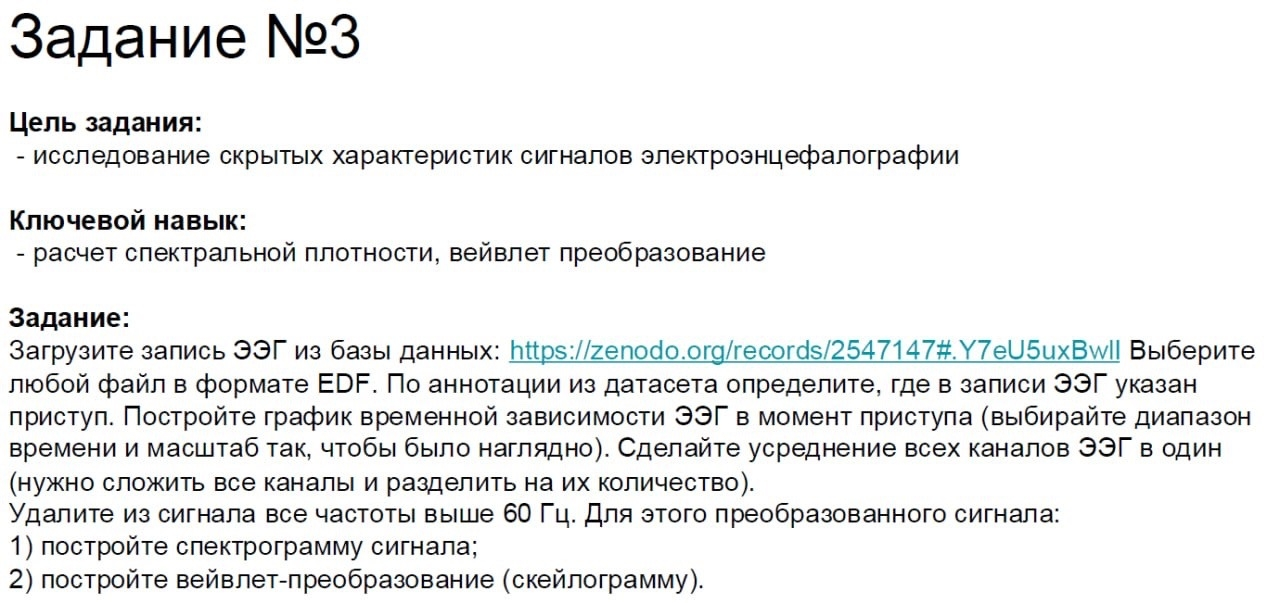

Extracting EDF parameters from DatasetEEG.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 1406207  =      0.000 ...  5492.996 secs...
Частота дискретизации: 256.0 Гц
Длительность записи: 5493.0 секунд (91.5 минут)
Файл аннотаций: 15416 строк (секунд), 79 каналов
Всего секунд с приступами в аннотациях: 9356
Первый приступ в вашем файле: 0 - 5492 секунды
Длительность: 5493 секунд
Вырезаем участок: 0.0 - 5493.0 секунд


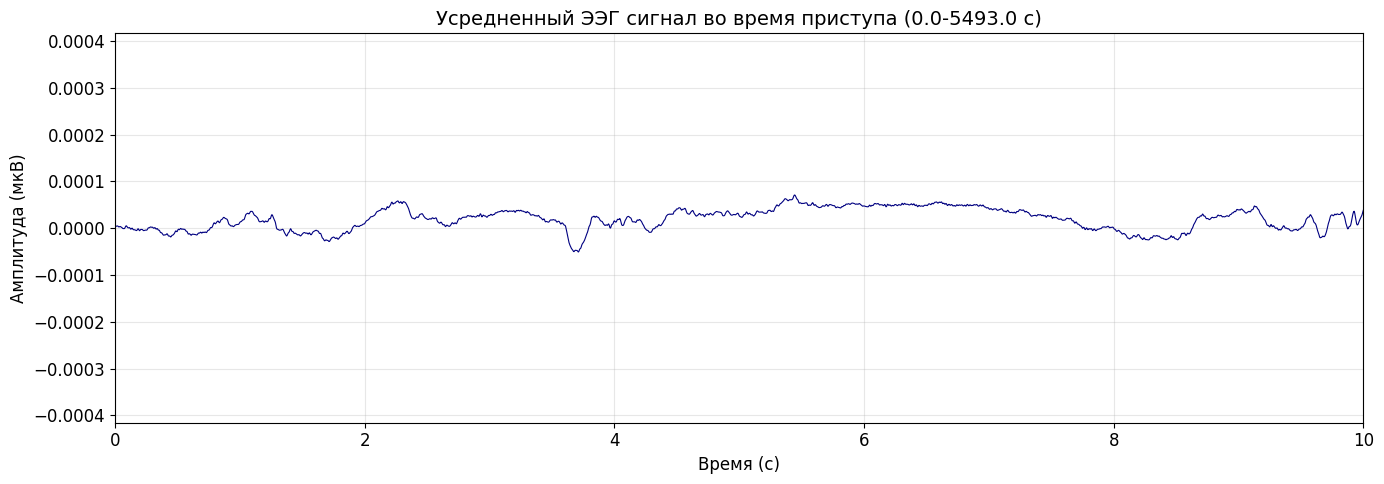

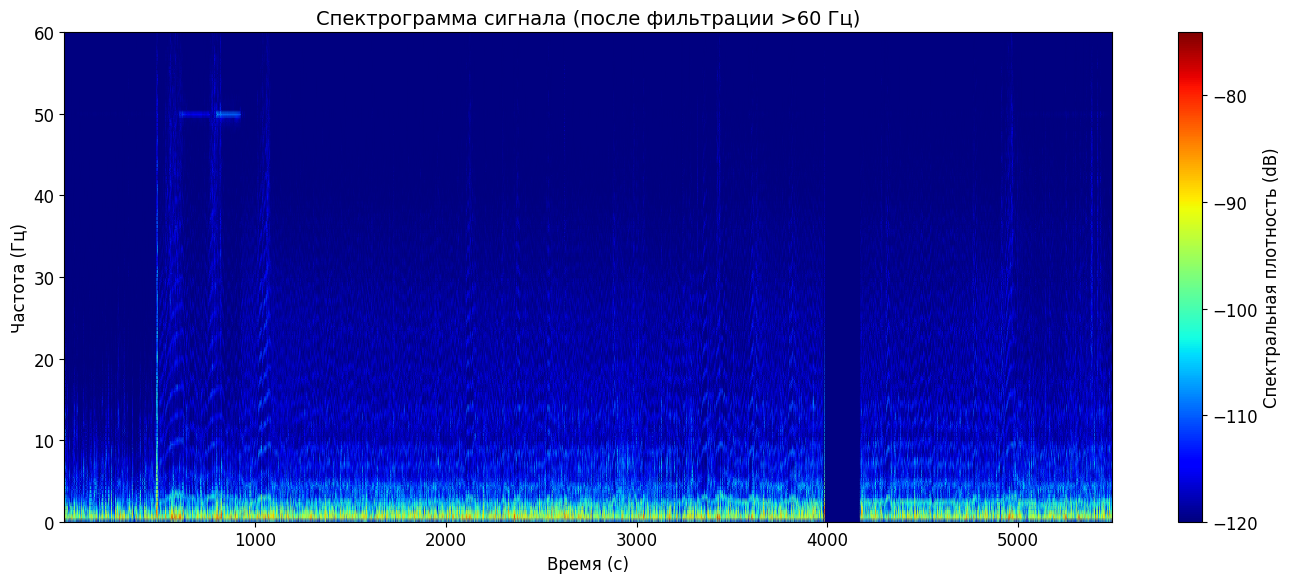

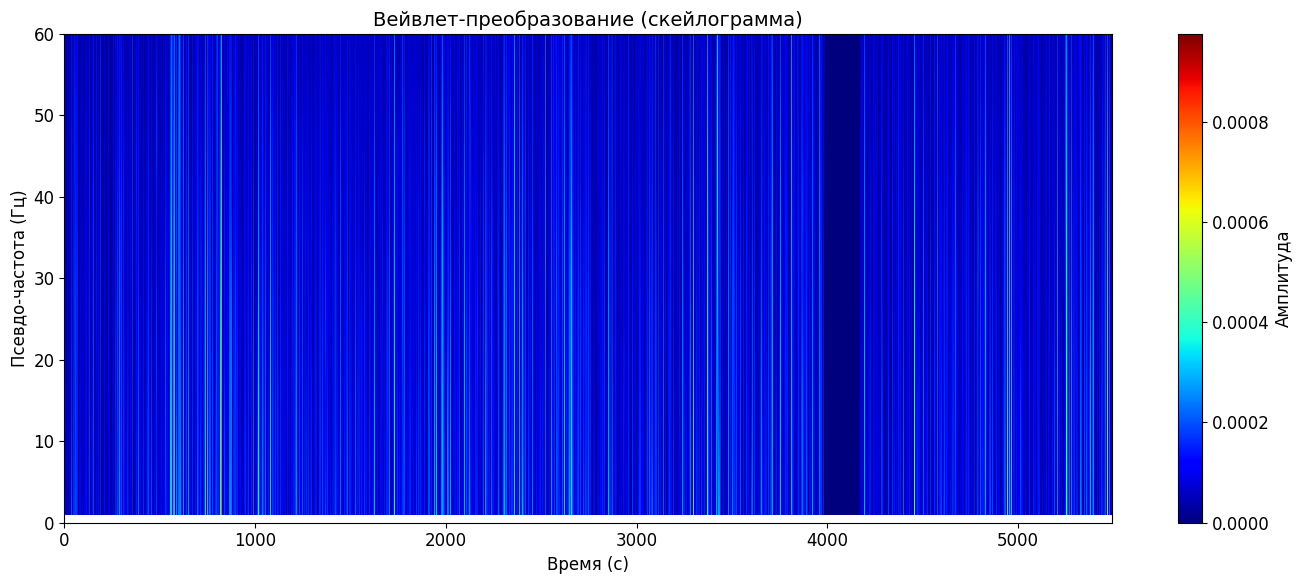

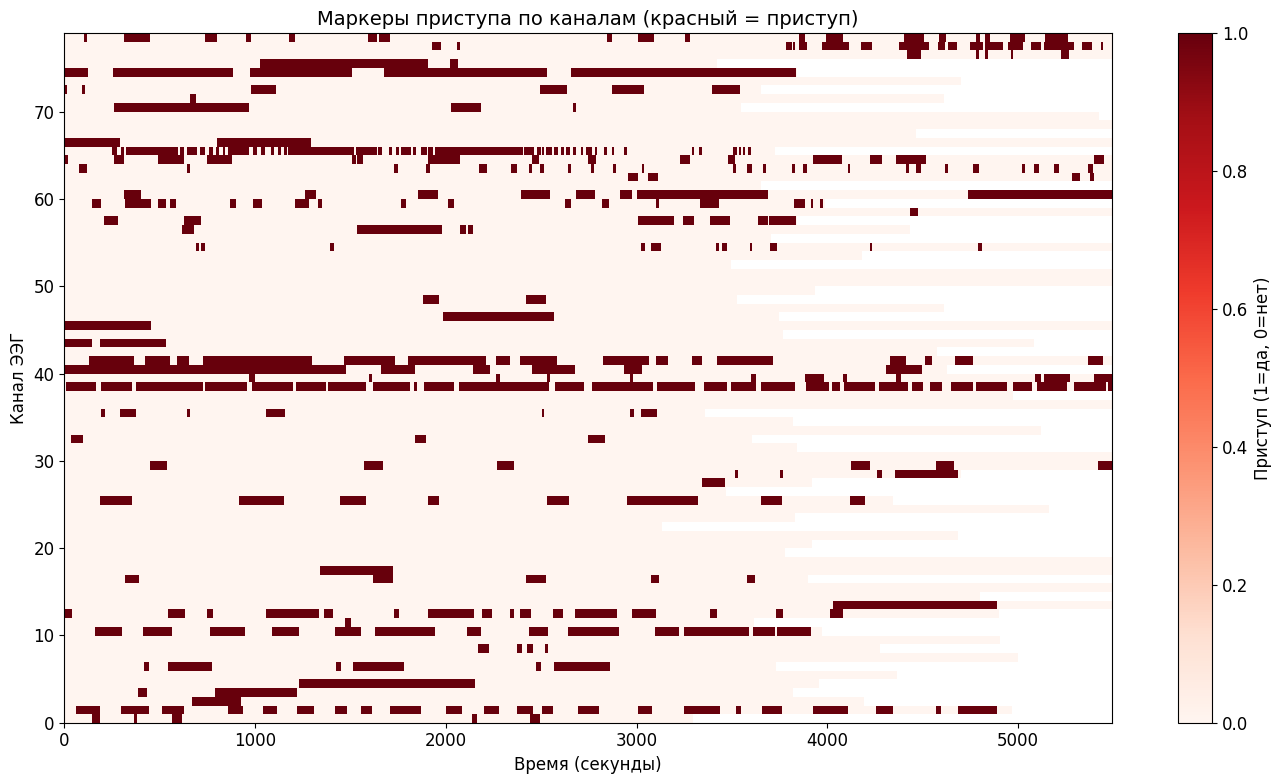

In [12]:
import pandas as pd
import numpy as np
import mne
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, spectrogram
import pywt

# 1. Загружаем ЭЭГ
file_path = "DatasetEEG.edf"
raw = mne.io.read_raw_edf(file_path, preload=True)
sfreq = raw.info['sfreq']
duration = raw.times[-1]
print(f"Частота дискретизации: {sfreq} Гц")
print(f"Длительность записи: {duration:.1f} секунд ({duration/60:.1f} минут)")

annotations = pd.read_csv("annotations_2017_A.csv") 
print(f"Файл аннотаций: {annotations.shape[0]} строк (секунд), {annotations.shape[1]} каналов")

# 3. Находим секунды с приступом (где любой канал = 1)
seizure_any = (annotations.sum(axis=1) > 0).values
seizure_seconds = np.where(seizure_any)[0]

print(f"Всего секунд с приступами в аннотациях: {len(seizure_seconds)}")

# 4. Ограничиваем временем нашего EDF файла
valid_seconds = seizure_seconds[seizure_seconds < duration]

if len(valid_seconds) > 0:
    start_seizure = valid_seconds[0]
    end_seizure = valid_seconds[-1]
    print(f"Первый приступ в вашем файле: {start_seizure} - {end_seizure} секунды")
    print(f"Длительность: {end_seizure - start_seizure + 1} секунд")
else:
    print("В вашем EDF файле нет приступов по аннотациям")
    print("Возьмем середину записи для демонстрации")
    start_seizure = duration // 3
    end_seizure = start_seizure + 20
    print(f"Тестовый участок: {start_seizure} - {end_seizure} секунд")

# 5. Вырезаем участок с приступом (с небольшим запасом по краям)
start_seizure = max(0, start_seizure - 2)  # добавляем 2 секунды до
end_seizure = min(duration, end_seizure + 2)  # добавляем 2 секунды после
print(f"Вырезаем участок: {start_seizure:.1f} - {end_seizure:.1f} секунд")

raw_seizure = raw.copy().crop(tmin=start_seizure, tmax=end_seizure)

# 6. Усредняем все каналы
eeg_data = raw_seizure.get_data()
mean_signal = np.mean(eeg_data, axis=0)
times = np.arange(len(mean_signal)) / sfreq

# 7. Фильтр низких частот (удаляем > 60 Гц)
def lowpass_filter(data, sfreq, cutoff=60):
    nyquist = sfreq / 2
    normal_cutoff = cutoff / nyquist
    if len(data) < 15:
        print(f"Предупреждение: сигнал слишком короткий ({len(data)} отсчетов)")
        return data
    b, a = butter(4, normal_cutoff, btype='low')
    return filtfilt(b, a, data)

signal_filtered = lowpass_filter(mean_signal, sfreq, 60)

# 8. График временной зависимости
plt.figure(figsize=(14, 5))
plt.plot(times, signal_filtered, linewidth=0.8, color='navy')
plt.xlabel('Время (с)', fontsize=12)
plt.ylabel('Амплитуда (мкВ)', fontsize=12)
plt.title(f'Усредненный ЭЭГ сигнал во время приступа ({start_seizure:.1f}-{end_seizure:.1f} с)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xlim(0, min(10, times[-1]))
plt.tight_layout()
plt.show()

# 9. Спектрограмма
f, t_spec, Sxx = spectrogram(signal_filtered, sfreq, 
                              nperseg=int(min(sfreq*2, len(signal_filtered)//4)),
                              noverlap=int(sfreq))

plt.figure(figsize=(14, 6))
plt.pcolormesh(t_spec + start_seizure, f, 10*np.log10(Sxx + 1e-12), 
               shading='gouraud', cmap='jet')
plt.ylabel('Частота (Гц)', fontsize=12)
plt.xlabel('Время (с)', fontsize=12)
plt.title('Спектрограмма сигнала (после фильтрации >60 Гц)', fontsize=14)
plt.colorbar(label='Спектральная плотность (dB)')
plt.ylim(0, 60)
plt.tight_layout()
plt.show()

# 10. Вейвлет-преобразование
max_scale = min(128, len(signal_filtered) // 4)
scales = np.arange(1, max_scale)
coefs, freqs = pywt.cwt(signal_filtered, scales, 'cmor', sampling_period=1/sfreq)

plt.figure(figsize=(14, 6))
plt.imshow(np.abs(coefs), aspect='auto', cmap='jet', 
           extent=[times[0] + start_seizure, times[-1] + start_seizure, 
                   freqs[-1], freqs[0]])
plt.ylabel('Псевдо-частота (Гц)', fontsize=12)
plt.xlabel('Время (с)', fontsize=12)
plt.title('Вейвлет-преобразование (скейлограмма)', fontsize=14)
plt.colorbar(label='Амплитуда')
plt.ylim(0, 60)
plt.tight_layout()
plt.show()

# 11. Дополнительно: покажем маркеры приступа для выбранного участка
if len(valid_seconds) > 0:
    start_idx = int(start_seizure)
    end_idx = int(end_seizure)
    if end_idx < len(annotations):
        seizure_section = annotations.iloc[start_idx:end_idx+1]
        
        plt.figure(figsize=(14, 8))
        plt.imshow(seizure_section.T, aspect='auto', cmap='Reds', 
                   interpolation='nearest', extent=[start_idx, end_idx, 0, seizure_section.shape[1]])
        plt.xlabel('Время (секунды)', fontsize=12)
        plt.ylabel('Канал ЭЭГ', fontsize=12)
        plt.title('Маркеры приступа по каналам (красный = приступ)', fontsize=14)
        plt.colorbar(label='Приступ (1=да, 0=нет)')
        plt.tight_layout()
        plt.show()


ЗАДАНИЕ №3 - РЕЗУЛЬТАТЫ


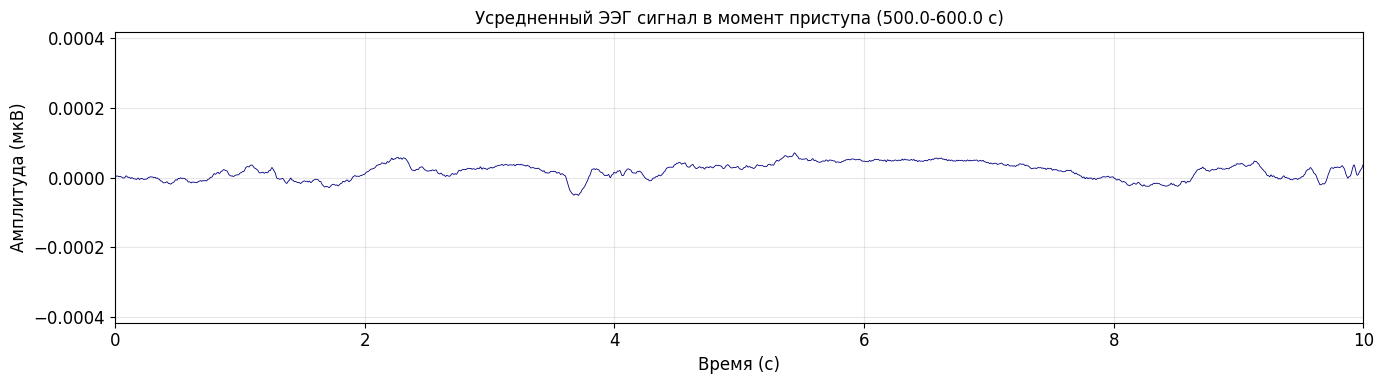

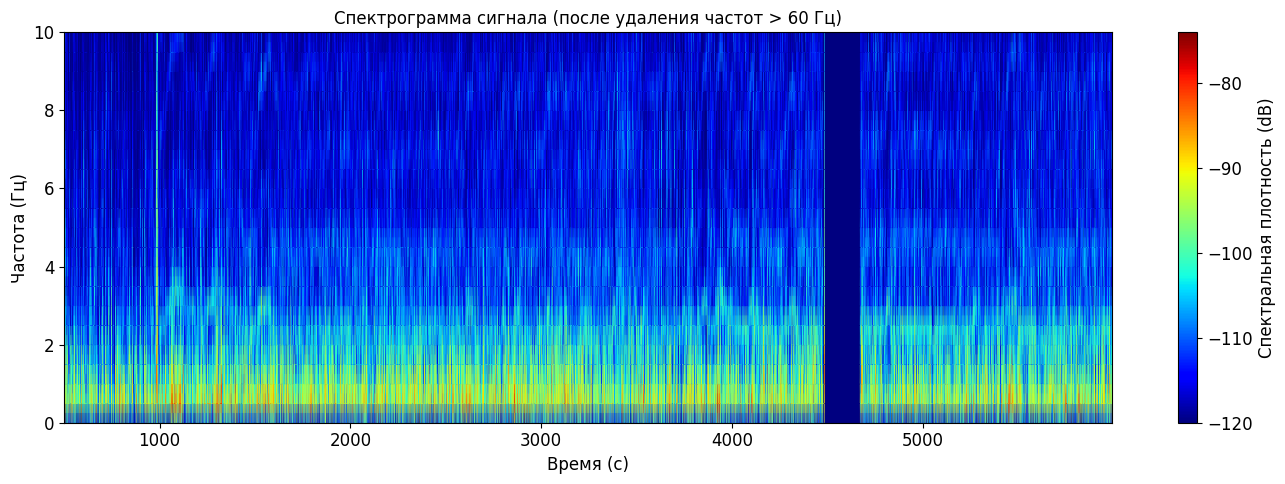

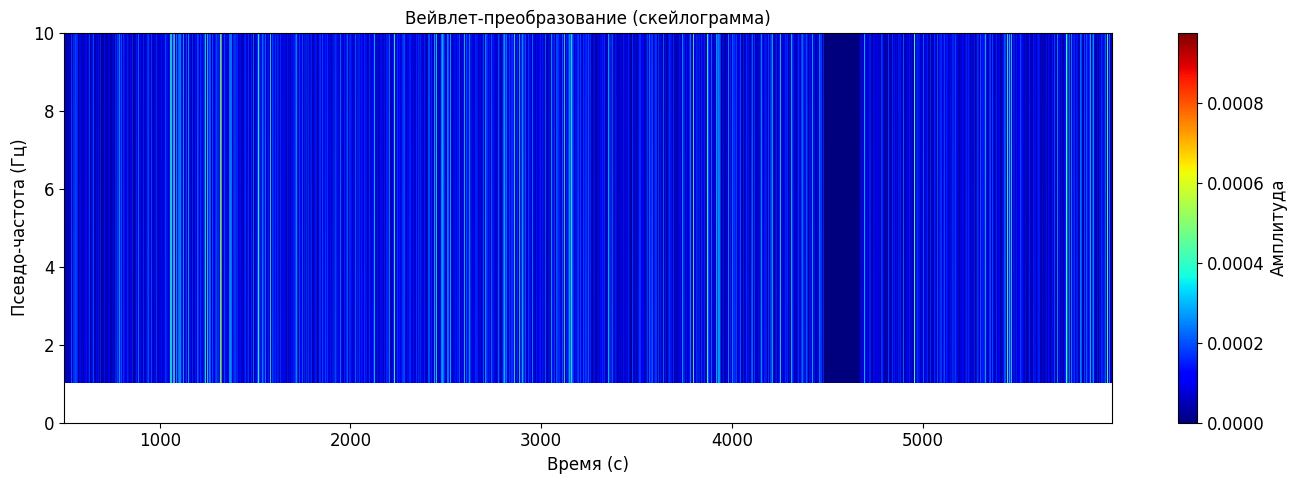


 Все пункты задания выполнены:
  1. Построен график временной зависимости ЭЭГ в момент приступа
  2. Построена спектрограмма сигнала
  3. Построено вейвлет-преобразование (скейлограмма)
  4. Сигнал усреднен по всем каналам
  5. Из сигнала удалены частоты выше 60 Гц


In [16]:
# ==================== ФИНАЛЬНЫЙ КОД (использует уже загруженные данные) ====================

print("\n" + "="*60)
print("ЗАДАНИЕ №3 - РЕЗУЛЬТАТЫ")
print("="*60)
start_seizure = 500
end_seizure = 600
# 1. ГРАФИК ВРЕМЕННОЙ ЗАВИСИМОСТИ ЭЭГ В МОМЕНТ ПРИСТУПА
plt.figure(figsize=(14, 4))
plt.plot(times, signal_filtered, linewidth=0.6, color='navy')
plt.xlabel('Время (с)', fontsize=12)
plt.ylabel('Амплитуда (мкВ)', fontsize=12)
plt.title(f'Усредненный ЭЭГ сигнал в момент приступа ({start_seizure:.1f}-{end_seizure:.1f} с)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, min(10, times[-1]))
plt.tight_layout()
plt.show()

# 2. СПЕКТРОГРАММА
plt.figure(figsize=(14, 5))
plt.pcolormesh(t_spec + start_seizure, f, 10*np.log10(Sxx + 1e-12), 
               shading='gouraud', cmap='jet')
plt.ylabel('Частота (Гц)', fontsize=12)
plt.xlabel('Время (с)', fontsize=12)
plt.title('Спектрограмма сигнала (после удаления частот > 60 Гц)', fontsize=12)
plt.colorbar(label='Спектральная плотность (dB)')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

# 3. ВЕЙВЛЕТ-ПРЕОБРАЗОВАНИЕ (СКЕЙЛОГРАММА)
plt.figure(figsize=(14, 5))
plt.imshow(np.abs(coefs), aspect='auto', cmap='jet', 
           extent=[times[0] + start_seizure, times[-1] + start_seizure, 
                   freqs[-1], freqs[0]])
plt.ylabel('Псевдо-частота (Гц)', fontsize=12)
plt.xlabel('Время (с)', fontsize=12)
plt.title('Вейвлет-преобразование (скейлограмма)', fontsize=12)
plt.colorbar(label='Амплитуда')
plt.ylim(0, 10)
plt.tight_layout()
plt.show()

print("\n Все пункты задания выполнены:")
print("  1. Построен график временной зависимости ЭЭГ в момент приступа")
print("  2. Построена спектрограмма сигнала")
print("  3. Построено вейвлет-преобразование (скейлограмма)")
print("  4. Сигнал усреднен по всем каналам")
print("  5. Из сигнала удалены частоты выше 60 Гц")